# Análisis e Identificación de Patrones de Fraude

Este cuaderno de Jupyter realiza una simulación de **300 transacciones financieras** para evaluar y visualizar patrones de fraude basados en el **monto** de la transacción y la **hora del día**.

---

## 1. Importación de Librerías
Cargamos las librerías necesarias para procesar arreglos numéricos (`numpy`), manipular tablas de datos (`pandas`) y generar la visualización gráfica (`matplotlib`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Generación de Datos Sintéticos

Para simular el escenario, creamos variables como:
* **Fijación de semilla (`seed=42`)**: Asegura que los números aleatorios generados sean reproducibles cada vez que se ejecute la celda.
* **Hora del día**: Valores enteros entre 0 y 23 horas.
* **Monto**: Generado con una distribución exponencial para modelar montos frecuentemente bajos y pocos montos altos.
* **Probabilidad de fraude**: 
  * Probabilidad base del `3%`.
  * Incremento de `+35%` si la transacción ocurre en la madrugada (de 0 a 5 hrs o a las 23 hrs).
  * Incremento de `+25%` si el monto supera los **S/ 400**.
  * Probabilidad tope fijada en `90%` máximo.

In [2]:
# Definición de semilla y volumen de datos
np.random.seed(42)
n = 300

# Simulación de variables independientes
hora = np.random.randint(0, 24, n)
monto = np.random.exponential(scale=150, size=n) + 10

# Reglas de negocio para calcular la probabilidad de fraude
prob_fraude = 0.03 + 0.35 * ((hora <= 5) | (hora >= 23)) + 0.25 * (monto > 400)
prob_fraude = np.clip(prob_fraude, 0, 0.9)

# Simulación de la variable objetivo (0: Legítima, 1: Fraude)
es_fraude = (np.random.rand(n) < prob_fraude).astype(int)

# Estructuración en DataFrame de pandas
transacciones = pd.DataFrame({"hora": hora, "monto": monto, "es_fraude": es_fraude})

# Visualización de los primeros 5 registros
transacciones.head()

,hora,monto,es_fraude
0,6,99.246385,0
1,19,789.295431,0
2,14,39.024106,0
3,10,12.736108,0
4,7,112.151287,0


## 3. Configuración de la Paleta y Área de Dibujo

Establecemos la identidad visual para el gráfico:
* **Verde (`#0ca30c`)**: Transacciones legítimas.
* **Rojo (`#d03b3b`)**: Transacciones fraudulentas.
* Se crea un área de dibujo (*figure y axes*) con fondo beige claro (`#fcfcfb`) de dimensiones $10 \times 6$ pulgadas.

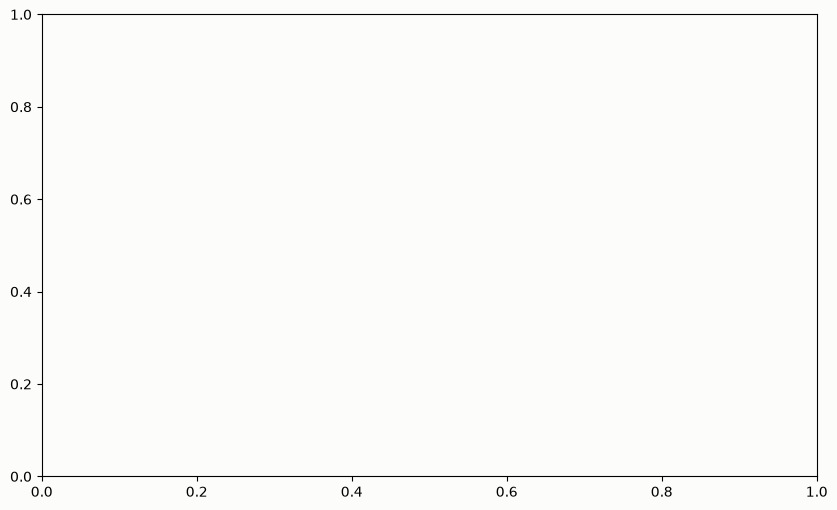

In [3]:
# Mapeos visuales
colores = {0: "#0ca30c", 1: "#d03b3b"}
etiquetas = {0: "Legítima", 1: "Fraude"}

# Creación de la figura
fig, ax = plt.subplots(figsize=(10, 6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

## 4. Renderizado, Estilización y Resumen

Dibujamos los puntos en el diagrama de dispersión (*Scatter Plot*), aplicamos formato a los ejes, títulos y márgenes, y finalmente mostramos las métricas cuantitativas básicas del conjunto de datos.

In [5]:
# Renderizado de puntos divididos por tipo de transacción
for valor in [0, 1]:
    subset = transacciones[transacciones["es_fraude"] == valor]
    ax.scatter(
        subset["hora"], subset["monto"],
        s=70, alpha=0.75,
        c=colores[valor],
        edgecolors="white", linewidths=0.6,
        label=etiquetas[valor],
    )

# Configuración de textos e información de ejes
ax.set_title("Transacciones por hora y monto", fontsize=15, color="#0b0b0b", pad=14)
ax.set_xlabel("Hora del día", fontsize=11, color="#52514e")
ax.set_ylabel("Monto (S/)", fontsize=11, color="#52514e")
ax.set_xticks(range(0, 24, 2))

# Estilo gráfico y cuadrícula
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Tipo de transacción", frameon=False, loc="upper right")

# Mostrar gráfico
plt.tight_layout()
plt.show()

# Imprimir métricas cuantitativas
print("Total transacciones:", len(transacciones), "| Fraudes registrados:", transacciones["es_fraude"].sum())

<Figure size 640x480 with 0 Axes>

Total transacciones: 300 | Fraudes registrados: 50
